# Predicting rural water point failure in Zambia

**A walkthrough of the whole project, in the order it actually happened.**

Buseko Fungamwango &middot; Insight Analytics Ltd &middot; SDG 6, Clean Water and Sanitation

---

## What this notebook is

This is the narrative version of the code in `src/`. Same data, same decisions,
same numbers, but with the reasoning written down between the steps and the
dead ends left in.

The short version of the story: I set out to predict which rural water points
in Zambia are broken, found three separate traps in the data that would each
have produced an impressive and completely false result, fixed all three, and
ended up with a model that **loses to a one-line rule**.

I published that result rather than hiding it, and the reason it matters is at
the end.

## The question

Roughly a third of rural handpumps in sub-Saharan Africa are non-functional at
any given time. Repair crews are few and districts are large. If you could rank
water points by how likely they are to be broken, a crew could visit the
worst-looking ones first instead of driving at random.

So: **given a water point's age, type, location and the population it serves,
can we predict whether it is working?**

## How to read this

| Section | What happens |
|---|---|
| 1 to 2 | Load the raw data and look at it properly before modelling anything |
| 3 to 5 | The three traps, each found by counting rather than by modelling |
| 6 to 7 | Build the modelling table, with every exclusion stated |
| 8 to 10 | Split honestly, compare models, and measure what a careless split would have bought me |
| 11 to 13 | Score once on unseen districts, then answer the operational question |
| 14 to 16 | What the model leaned on, what the ablation said, and what I would defend |

## 1. Setup

Everything is loaded from the repository itself, so this notebook reproduces
the committed results rather than restating them.

In [1]:
import json
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# Run from anywhere inside the repo.
ROOT = Path.cwd()
while not (ROOT / "src" / "data_prep.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.width", 110)
pd.set_option("display.max_columns", 40)

# One consistent look for every chart in the notebook.
NAVY, GOLD, SLATE, RUST = "#14213D", "#D6AF7B", "#6B7A8F", "#B0632A"
mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110,
    "font.size": 9.5, "axes.titlesize": 11, "axes.titleweight": "600",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "figure.facecolor": "white", "axes.facecolor": "white",
})

print("repo root:", ROOT)
print("pandas", pd.__version__, "| numpy", np.__version__)
import sklearn; print("scikit-learn", sklearn.__version__)

repo root: C:\Users\All\Desktop\sdg6-zambia-water-points
pandas 2.3.3 | numpy 2.3.5


scikit-learn 1.7.2


## 2. The raw data

The source is the **Water Point Data Exchange (WPdx)**, obtained through the UN
OCHA Humanitarian Data Exchange. It is a shared register that governments,
NGOs and donor programmes all contribute water point records to.

<https://data.humdata.org/dataset/wpdx_zmb> &middot; licensed CC BY-SA

One detail that matters immediately: **row 2 of the file is not data.** It is a
row of HXL humanitarian markup tags. Read the file naively and every numeric
column arrives as text.

In [2]:
from data_prep import (
    RAW, TARGET, GROUP, NUMERIC_FEATURES, CATEGORICAL_FEATURES,
    RANDOM_STATE, EXCLUSIONS, load_raw, build_label,
    drop_single_class_programmes, engineer_features,
)

raw = load_raw()   # skiprows=[1] drops the HXL tag row
print(f"{raw.shape[0]:,} rows x {raw.shape[1]} columns")
print(f"Reporting period: {raw['report_date'].min()} to {raw['report_date'].max()}")
print(f"Contributing programmes: {raw['dataset_title'].nunique()}")
print(f"Districts: {raw['clean_adm2'].nunique()}   Provinces: {raw['clean_adm1'].nunique()}")

6,643 rows x 54 columns
Reporting period: 2012-01-01 to 2025-12-07
Contributing programmes: 15
Districts: 79   Provinces: 10


In [3]:
# What is actually usable? Missingness first, before any modelling ideas.
miss = raw.isna().mean().mul(100).sort_values(ascending=False)
print("Emptiest columns (% missing):")
print(miss.head(12).round(1).to_string())
print()
print("Most complete columns (% missing):")
print(miss.tail(10).round(1).to_string())

Emptiest columns (% missing):
predicted_category      100.0
prediction_yes_2y       100.0
pay_clean               100.0
clean_adm3              100.0
prediction_yes_0y       100.0
clean_adm4              100.0
prediction_no_0y        100.0
prediction_no_2y        100.0
predicted_status_2y     100.0
predicted_status_0y     100.0
rehab_year              100.0
fecal_coliform_value     99.1

Most complete columns (% missing):
clean_country_name    0.0
clean_adm1            0.0
usage_cap             0.0
clean_adm2            0.0
dataset_title         0.0
created_timestamp     0.0
facility_type         0.0
wpdx_id               0.0
lon_deg               0.0
lat_deg               0.0


## 3. Trap one: the label is corrupted

There are two columns that look like they answer "does this water point work?"

- `status_clean` &mdash; a tidy Functional / Non-Functional category
- `status_id` &mdash; a raw Yes / No / Unknown, meaning "was water available on the day of the visit?"

`status_clean` is the obvious choice. It is cleaner, it has no Unknowns, and it
is what the column name promises.

**It is also wrong.** Before trusting a label, cross-tabulate it against who
supplied the record.

In [4]:
# Who reports what? One row per contributing programme.
audit = (raw.assign(clean=raw["status_clean"].fillna("(blank)"))
            .pivot_table(index="dataset_title", columns="clean",
                         values="wpdx_id", aggfunc="count", fill_value=0))
audit["n"] = audit.sum(axis=1)

# Share of each programme's points that status_id says had water available.
water_yes = (raw.assign(yes=(raw["status_id"] == "Yes").astype(int))
                .groupby("dataset_title")["yes"].mean().mul(100).round(1))
audit["status_id says water available %"] = water_yes

audit = audit.sort_values("n", ascending=False)
audit.index = [t[:46] for t in audit.index]
print(f"{len(audit)} contributing programmes\n")
print(audit.to_string())

15 contributing programmes

clean                                           Functional  Non-Functional     n  status_id says water available %
SNV Zambia_Zambia_2014                                1745             356  2101                              83.9
Water4_Global_2021-2022                                  0            1479  1479                              97.8
World Vision_Africa Boreholes_2011-2015                  0             825   825                              48.6
Village Water_Zambia_2009-2018                           0             444   444                              88.7
Living Water International_Global_2019-2020              0             443   443                              99.5
Village Water_Zambia Mozambique_2009-2021                0             429   429                             100.0
Living Water International_Global_September202           0             275   275                              93.8
UNHCR_Global_2022                                   

Read the `Functional` column.

Of the fifteen contributing programmes, **exactly one ever records the word
"Functional"**. Every other programme has all of its water points labelled
`Non-Functional`, including programmes where `status_id` says water was flowing
at 100% of the points visited.

That is not a country where every pump is broken. It is a column where a
**missing value has been written down as a category**. `status_clean` measures
who uploaded the record, not whether the water point works.

The comparison in one line:

In [5]:
print("If I had trusted status_clean:")
sc = raw["status_clean"].value_counts(dropna=False)
print(f"  Non-Functional: {sc.get('Non-Functional', 0):,}")
print(f"  Functional:     {sc.get('Functional', 0):,}")
print(f"  -> apparent failure rate: "
      f"{sc.get('Non-Functional', 0) / sc.sum() * 100:.1f}%")

print("\nWhat status_id actually records:")
si = raw["status_id"].value_counts(dropna=False)
print(si.to_string())
usable = si.get("Yes", 0) + si.get("No", 0)
print(f"  -> real failure rate among visited points: "
      f"{si.get('No', 0) / usable * 100:.1f}%")

If I had trusted status_clean:
  Non-Functional: 4,898
  Functional:     1,745
  -> apparent failure rate: 73.7%

What status_id actually records:
status_id
Yes        5721
No          476
Unknown     446
  -> real failure rate among visited points: 7.7%


A 73.7% national failure rate versus a 7.7% one. Publishing the first number
would have been a serious thing to get wrong, and nothing in the modelling
would ever have revealed it. Only counting did.

(The 7.7% here is across every point with a real observation. It rises to 11.8%
in section 5, once the programmes that never record a failure are removed.)

`status_id` becomes the label. `Unknown` is **dropped rather than guessed**:
assigning those rows to either class would invent observations nobody made.

In [6]:
labelled = build_label(raw)
print(f"Kept {len(labelled):,} rows with a real Yes/No observation")
print(f"Dropped {len(raw) - len(labelled):,} rows where status was Unknown")
print(f"Failure rate: {labelled[TARGET].mean() * 100:.1f}%")

Kept 6,197 rows with a real Yes/No observation
Dropped 446 rows where status was Unknown
Failure rate: 7.7%


## 4. Trap two: two columns contain the answer

With an honest label, I trained a Random Forest. It scored **ROC-AUC 0.998**.

That is not a good sign. Real problems are not that easy, and a near-perfect
score usually means the answer has leaked into the features.

The test for leakage is simple: for each column, ask how often it is populated
for broken points versus working ones. A feature that is present for one class
and absent for the other is not a predictor. It is a label in disguise.

In [7]:
def population_by_class(df, cols):
    """How often is each column filled in, split by the outcome?"""
    rows = []
    for c in cols:
        present = df[c].notna()
        rows.append({
            "column": c,
            "% filled when BROKEN": round(present[df[TARGET] == 1].mean() * 100, 1),
            "% filled when WORKING": round(present[df[TARGET] == 0].mean() * 100, 1),
        })
    out = pd.DataFrame(rows)
    out["gap"] = out["% filled when BROKEN"] - out["% filled when WORKING"]
    return out.sort_values("gap", ascending=False)

suspects = ["rehab_priority", "would_gain_access", "subjective_quality",
            "notes", "install_year", "local_population", "water_tech_clean"]
print(population_by_class(labelled, suspects).to_string(index=False))

            column  % filled when BROKEN  % filled when WORKING   gap
 would_gain_access                  99.6                    0.0  99.6
    rehab_priority                  96.8                    0.0  96.8
subjective_quality                  71.4                   35.4  36.0
  local_population                  96.8                   75.2  21.6
  water_tech_clean                  96.8                   88.4   8.4
      install_year                  94.5                   95.8  -1.3
             notes                   6.7                   20.8 -14.1


There they are.

`rehab_priority` is filled in for **96.8%** of broken points and **0.0%** of
working ones. `would_gain_access` is filled in for **99.6%** of broken points
and **0.0%** of working ones.

Neither is a measurement of the water point. Both are **rehabilitation planning
notes, written after somebody already knew the point had failed**. A model using
them is not predicting failure, it is reading a repair queue.

I will keep this as a live demonstration and put `rehab_priority` back in
later, in section 11, to show exactly what it was worth.

## 5. Trap three: the programmes that never fail

One more count, and this one is easy to miss because the column looks harmless.

How many failures does each contributing programme report?

In [8]:
_, programme_rates = drop_single_class_programmes(labelled)
pr = programme_rates.copy()
pr.index = [t[:52] for t in pr.index]
pr["failure_rate %"] = (pr["failure_rate"] * 100).round(1)
print(pr[["n", "failures", "failure_rate %"]].to_string())

zero = pr[pr["failures"] == 0]
print(f"\n{len(zero)} of {len(pr)} programmes report ZERO failures, "
      f"covering {int(zero['n'].sum()):,} water points.")

                                                         n  failures  failure_rate %
SNV Zambia_Zambia_2014                                2101       339            16.1
Water4_Global_2021-2022                               1447         0             0.0
World Vision_Africa Boreholes_2011-2015                445        44             9.9
Village Water_Zambia_2009-2018                         444        50            11.3
Living Water International_Global_2019-2020            443         2             0.4
Village Water_Zambia Mozambique_2009-2021              429         0             0.0
Living Water International_Global_September2022        275        17             6.2
UNHCR_Global_2022                                      217        11             5.1
Living Water International_Africa Latin America_Oct2   133         0             0.0
WPDx Reingestion_Global                                101        13            12.9
WaterAid_Global_2019-2020                               87       

Seven programmes, 2,171 water points, and not a single failure between them.

No water programme in the world has a 0% failure rate. What is really happening
is a reporting convention: **those programmes upload their points at handover**,
on the day of installation, when everything works by definition, and never
return to update the record.

Left in, a model learns "points from Programme X never break". It can reach that
conclusion without ever seeing the programme name, because programme correlates
with district, with installation year, and with location. The result would look
like geography and would actually be paperwork.

So those programmes come out. Note what this costs: it is not free.

In [9]:
modelling, _ = drop_single_class_programmes(labelled)
print(f"Before: {len(labelled):,} points, {labelled[TARGET].mean()*100:.1f}% failure rate")
print(f"After:  {len(modelling):,} points, {modelling[TARGET].mean()*100:.1f}% failure rate")
print(f"\nCost of this decision: {len(labelled) - len(modelling):,} points removed "
      f"({(1 - len(modelling)/len(labelled))*100:.0f}% of the labelled data).")
print("Kept because a programme with no failures carries no information about failure.")

Before: 6,197 points, 7.7% failure rate
After:  4,026 points, 11.8% failure rate

Cost of this decision: 2,171 points removed (35% of the labelled data).
Kept because a programme with no failures carries no information about failure.


## 6. Every exclusion, stated

Nothing is dropped silently. This is the full list from `src/data_prep.py`,
printed so the audit trail lives in the output rather than only in a README.

In [10]:
for cols, reason in EXCLUSIONS.items():
    head = cols if len(cols) < 62 else cols[:59] + "..."
    print(f"* {head}")
    print(f"    {' '.join(reason.split())[:230]}")
    print()

* status_clean


    CORRUPTED LABEL. Only one of the 15 contributing programmes ever records 'Functional'. Every other programme has all of its points labelled 'Non-Functional', including programmes where status_id says water is available for 100% of

* rehab_priority
    TARGET LEAKAGE. Populated for 96.8% of non-functional points and 0.0% of functional ones. It is a rehabilitation queue built after the status was known.

* would_gain_access
    TARGET LEAKAGE. Populated for 99.6% of non-functional points and 0.0% of functional ones.

* subjective_quality
    LEAKAGE RISK. Recorded by the same enumerator on the same visit that produced the status. 64% missing and not independently verifiable.

* assigned_population,pressure,criticality,usage_cap
    WPdx service-allocation outputs. These are computed by WPdx rather than observed in the field, and the allocation logic may already know which points are working. Excluded as a conservative choice; see the limitations section of t

* source,dataset_title

### Feature engineering

Only one derived feature really matters, and it is the physically obvious one:
**how old was the pump when somebody looked at it?**

The raw file contains install years as early as 1902, which predates any
borehole programme in Zambia by decades. Those are data entry errors, not very
old pumps, so they are blanked and imputed rather than believed.

In [11]:
modelling = engineer_features(modelling)

install = pd.to_numeric(modelling["install_year"], errors="coerce")
bad = ((install < 1950) | (install > modelling["report_year"])).sum()
print(f"Implausible install years blanked: {bad:,}")
print(f"\nAge at inspection (years):")
print(modelling["age_years"].describe().round(1).to_string())
print(f"\nMissing age: {modelling['age_years'].isna().mean()*100:.1f}%")

Implausible install years blanked: 27

Age at inspection (years):
count    3742.0
mean        6.1
std         8.0
min         0.0
25%         1.0
50%         3.0
75%         9.0
max        58.0

Missing age: 7.1%


## 7. The modelling table

In [12]:
keep = NUMERIC_FEATURES + CATEGORICAL_FEATURES + [TARGET, GROUP, "report_year", "wpdx_id"]
df = modelling[keep].copy()

print(f"{len(df):,} water points x {len(NUMERIC_FEATURES) + len(CATEGORICAL_FEATURES)} features")
print(f"Non-functional: {df[TARGET].sum():,} ({df[TARGET].mean()*100:.1f}%)")
print(f"Districts: {df[GROUP].nunique()}   Provinces: {df['clean_adm1'].nunique()}")
print(f"\nClass balance is {df[TARGET].mean()*100:.0f}/{(1-df[TARGET].mean())*100:.0f}, "
      f"so accuracy is a useless metric here.")
print("A model predicting 'never broken' would score 88% accurate and be worthless.")
print("PR-AUC is the headline metric throughout; it only rewards finding the rare class.")
df.head(3)

4,026 water points x 15 features
Non-functional: 476 (11.8%)


Districts: 61   Provinces: 10

Class balance is 12/88, so accuracy is a useless metric here.
A model predicting 'never broken' would score 88% accurate and be worthless.
PR-AUC is the headline metric throughout; it only rewards finding the rare class.


,age_years,local_population,distance_to_city,distance_to_town,distance_to_primary,distance_to_secondary,distance_to_tertiary,lat_deg,lon_deg,water_source_clean,water_tech_clean,water_source_category,water_tech_category,clean_adm1,is_urban,is_non_functional,clean_adm2,report_year,wpdx_id
0,NaN,2015.0,NaN,71162.697262,86646.867859,6591.132366,859.564962,-14.540310,24.194580,Protected Well,Hand Pump,Well,Hand Pump,Western,False,0,Kaoma,2019,5GQ6F55V+VRG
1,NaN,1040.0,NaN,69258.575738,87248.107418,5043.401989,89.929786,-14.537210,24.215440,Protected Well,Hand Pump,Well,Hand Pump,Western,False,0,Kaoma,2019,5GQ6F678+458
2,2.0,89.0,60773.115906,16811.725233,47233.301961,12006.164927,2932.781097,-15.300167,28.835333,Borehole/Tubewell,NaN,Well,NaN,Lusaka,False,0,Rufunsa,2018,5GPCMRXP+W4P


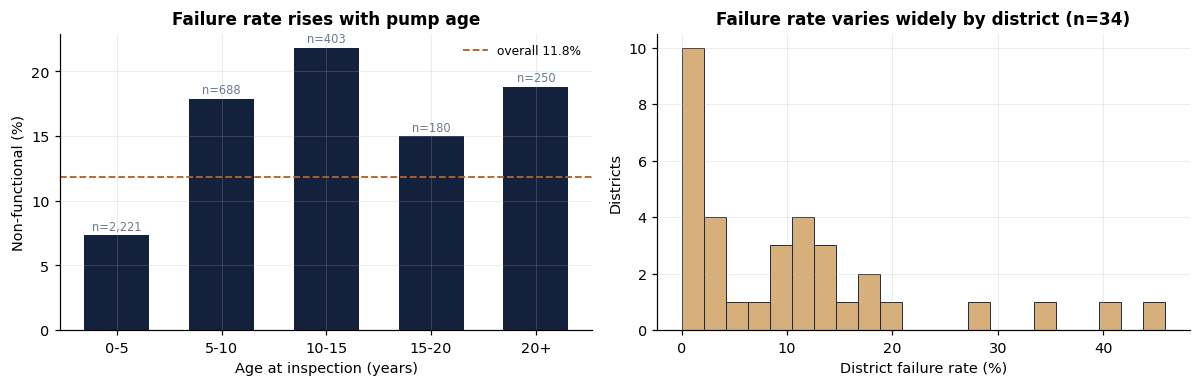

District failure rates run from 0% to 46%.
That spread is exactly why the train/test split has to respect districts.


In [13]:
# A first look at the one feature with a physical story behind it.
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

bins = [0, 5, 10, 15, 20, 60]
labels = ["0-5", "5-10", "10-15", "15-20", "20+"]
band = pd.cut(df["age_years"], bins=bins, labels=labels, right=False)
rate = df.groupby(band, observed=True)[TARGET].agg(["mean", "size"])

axes[0].bar(rate.index.astype(str), rate["mean"] * 100, color=NAVY, width=0.62)
for i, (m, n) in enumerate(zip(rate["mean"], rate["size"])):
    axes[0].text(i, m * 100 + 0.4, f"n={n:,}", ha="center", fontsize=7.5, color=SLATE)
axes[0].axhline(df[TARGET].mean() * 100, color=RUST, ls="--", lw=1.2,
                label=f"overall {df[TARGET].mean()*100:.1f}%")
axes[0].set_title("Failure rate rises with pump age")
axes[0].set_xlabel("Age at inspection (years)"); axes[0].set_ylabel("Non-functional (%)")
axes[0].legend(frameon=False, fontsize=8)

dist = df.groupby(GROUP)[TARGET].agg(["mean", "size"]).query("size >= 20")
axes[1].hist(dist["mean"] * 100, bins=22, color=GOLD, edgecolor=NAVY, linewidth=0.6)
axes[1].set_title(f"Failure rate varies widely by district (n={len(dist)})")
axes[1].set_xlabel("District failure rate (%)"); axes[1].set_ylabel("Districts")

plt.tight_layout(); plt.show()

print(f"District failure rates run from {dist['mean'].min()*100:.0f}% "
      f"to {dist['mean'].max()*100:.0f}%.")
print("That spread is exactly why the train/test split has to respect districts.")

## 8. Splitting honestly

Here is the decision that changes the answer more than any model choice.

Water points in the same district share an installer, a water table, a spare
parts supply and a maintenance team. If I split rows at random, a point in the
validation fold usually sits a few hundred metres from a point the model
trained on. The model can recognise the neighbourhood instead of learning
anything that travels.

The question a planner actually has is: **"here is a district we have never
worked in, which points should we visit?"**

So validation holds out **whole districts**, using `StratifiedGroupKFold`
grouped on district. I report both numbers, because the gap between them is one
of the findings.

Two more things, both inside `Pipeline`:

- **Imputation and encoding are fitted per fold.** Fitting a median on the full
  dataset before splitting leaks the validation fold into training. It is a
  small leak and it is still a leak.
- **`add_indicator=True`** keeps the fact that a value was missing. A water
  point with no recorded install year is not an average water point, and that
  absence may say something about how well it is documented and looked after.

In [14]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, brier_score_loss,
                             roc_auc_score)
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from train import (MODEL_FEATURES, MODEL_NUMERIC, N_SPLITS, build_preprocessor,
                   candidate_models, cross_validate, inspection_curve, bootstrap_ci)

X, y, groups = df[MODEL_FEATURES], df[TARGET], df[GROUP]

outer = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
train_idx, test_idx = next(outer.split(X, y, groups))
X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
g_tr, g_te = groups.iloc[train_idx], groups.iloc[test_idx]

print(f"Train: {len(X_tr):,} points across {g_tr.nunique()} districts "
      f"({y_tr.mean()*100:.1f}% non-functional)")
print(f"Test:  {len(X_te):,} points across {g_te.nunique()} UNSEEN districts "
      f"({y_te.mean()*100:.1f}% non-functional)")
print(f"\nOverlap between train and test districts: "
      f"{len(set(g_tr) & set(g_te))} districts")
print(f"Held-out districts: {', '.join(sorted(set(g_te))[:6])}")

Train: 3,357 points across 56 districts (11.7% non-functional)
Test:  669 points across 5 UNSEEN districts (12.4% non-functional)

Overlap between train and test districts: 0 districts
Held-out districts: Chinsali, Chongwe, Lusaka, Mpulungu, Mushindano


## 9. Model comparison, against the rule that needs no model

Four candidates, plus the benchmark that actually matters.

That benchmark is **"visit the oldest pumps first"**. It requires no model, no
data science, and no budget. If a trained model cannot beat it, the model
should not be deployed, and saying so is the job.

It is scored on **identical folds**, so this is like for like.

In [15]:
grouped_cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True,
                                  random_state=RANDOM_STATE)
results, oof_store = {}, {}

for name, model in candidate_models().items():
    r = cross_validate(model, X_tr, y_tr, g_tr, grouped_cv)
    results[name] = {k: v for k, v in r.items() if k != "oof"}
    oof_store[name] = r["oof"]

tbl = pd.DataFrame([
    {"Model": n,
     "PR-AUC": f"{v['ap_mean']:.3f} +/- {v['ap_std']:.3f}",
     "ROC-AUC": f"{v['auc_mean']:.3f} +/- {v['auc_std']:.3f}"}
    for n, v in results.items()
])
rule = results["Random Forest"]
tbl.loc[len(tbl)] = ["NO MODEL: visit oldest first",
                     f"{rule['rule_ap']:.3f}", f"{rule['rule_auc']:.3f}"]
print("Cross-validation, grouped by district (5 folds):\n")
print(tbl.to_string(index=False))

Cross-validation, grouped by district (5 folds):

                        Model          PR-AUC         ROC-AUC
Baseline (predict prevalence) 0.106 +/- 0.028 0.500 +/- 0.000
          Logistic Regression 0.177 +/- 0.106 0.541 +/- 0.138
                Random Forest 0.239 +/- 0.147 0.614 +/- 0.133
            Gradient Boosting 0.185 +/- 0.093 0.565 +/- 0.119
 NO MODEL: visit oldest first           0.184           0.611


Look at the last row against the rest.

The Random Forest reaches **PR-AUC 0.239** against the age rule's **0.184**, so
on this measure the model is ahead. But look at the standard deviations: plus
or minus 0.147 across five folds. The folds disagree with each other about as
much as the model differs from the rule.

Logistic Regression and Gradient Boosting are both **worse than doing nothing
clever at all**.

## 10. What a careless split would have bought me

Same models, same data, same code. The only change is splitting **rows at
random** instead of holding out whole districts.

In [16]:
random_cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
rows = []
for name, model in candidate_models().items():
    if name.startswith("Baseline"):
        continue
    r = cross_validate(model, X_tr, y_tr, g_tr, random_cv)
    g = results[name]["ap_mean"]
    rows.append({"Model": name,
                 "Random split PR-AUC": round(r["ap_mean"], 3),
                 "District split PR-AUC": round(g, 3),
                 "Overstated by": f"+{r['ap_mean'] - g:.3f}",
                 "Inflation": f"{(r['ap_mean']/g - 1)*100:.0f}%"})
split_comparison = pd.DataFrame(rows)
print(split_comparison.to_string(index=False))

              Model  Random split PR-AUC  District split PR-AUC Overstated by Inflation
Logistic Regression                0.256                  0.177        +0.078       44%
      Random Forest                0.390                  0.239        +0.151       63%
  Gradient Boosting                0.344                  0.185        +0.159       86%


The Random Forest looks **63% better** under the random split. Nothing about
the model changed. Only the way I checked it changed.

This is the single most common way a machine learning result gets published
wrong, and it is invisible unless you go looking for it. Every number in that
"random split" column is real, reproducible, and misleading.

## 11. What the leaked column was worth

Now put `rehab_priority` back, as a simple present/absent flag, and rerun the
identical cross-validation.

In [17]:
flag_by_id = raw.set_index("wpdx_id")["rehab_priority"].notna().astype(int)
leak_flag = df.iloc[train_idx]["wpdx_id"].map(flag_by_id).fillna(0).astype(int)
leak_frame = X_tr.assign(rehab_priority_present=leak_flag.to_numpy())

leak_model = Pipeline([
    ("prep", build_preprocessor(scale=False,
                                numeric=MODEL_NUMERIC + ["rehab_priority_present"])),
    ("clf", RandomForestClassifier(n_estimators=500, min_samples_leaf=5,
                                   class_weight="balanced_subsample",
                                   random_state=RANDOM_STATE, n_jobs=-1)),
])
leak_r = cross_validate(leak_model, leak_frame, y_tr, g_tr, grouped_cv)

print(f"{'':<26s} {'PR-AUC':>8s} {'ROC-AUC':>9s}")
print(f"{'WITH rehab_priority':<26s} {leak_r['ap_mean']:>8.3f} {leak_r['auc_mean']:>9.3f}"
      f"   <- looks superb, predicts nothing")
print(f"{'WITHOUT it (honest)':<26s} {results['Random Forest']['ap_mean']:>8.3f} "
      f"{results['Random Forest']['auc_mean']:>9.3f}")
print(f"\nOne column moved ROC-AUC by "
      f"{leak_r['auc_mean'] - results['Random Forest']['auc_mean']:+.3f}.")
print("A model that good would have been deployed, and it would have been useless")
print("on any water point whose repair had not already been planned.")

                             PR-AUC   ROC-AUC
WITH rehab_priority           0.996     0.998   <- looks superb, predicts nothing
WITHOUT it (honest)           0.239     0.614

One column moved ROC-AUC by +0.385.
A model that good would have been deployed, and it would have been useless
on any water point whose repair had not already been planned.


## 12. The held-out districts, scored exactly once

Everything so far has happened inside the training districts. The five held-out
districts have not been touched, and they are scored **once**. No going back to
tune after seeing this.

The test set is small: 669 points with 83 failures. A point estimate alone
would overstate how much I know, so every metric gets a bootstrap confidence
interval.

In [18]:
best_name = max((n for n in results if not n.startswith("Baseline")),
                key=lambda n: results[n]["ap_mean"])
print(f"Selected on grouped CV: {best_name}\n")

best = candidate_models()[best_name]
best.fit(X_tr, y_tr)
p_te = best.predict_proba(X_te)[:, 1]
yte = y_te.to_numpy()

ap_lo, ap_hi = bootstrap_ci(yte, p_te, average_precision_score)
auc_lo, auc_hi = bootstrap_ci(yte, p_te, roc_auc_score)

med_age = X_tr["age_years"].median()
rule_te = X_te["age_years"].fillna(med_age).to_numpy()

print(f"Held-out: {len(yte)} points, {g_te.nunique()} districts, "
      f"{yte.sum()} broken ({yte.mean()*100:.1f}%)\n")
print(f"  {best_name}")
print(f"    PR-AUC   {average_precision_score(yte, p_te):.3f}   "
      f"95% CI [{ap_lo:.3f}, {ap_hi:.3f}]")
print(f"    ROC-AUC  {roc_auc_score(yte, p_te):.3f}   "
      f"95% CI [{auc_lo:.3f}, {auc_hi:.3f}]")
print(f"    Brier    {brier_score_loss(yte, p_te):.3f}")
print(f"\n  Age rule on exactly the same points")
print(f"    PR-AUC   {average_precision_score(yte, rule_te):.3f}")
print(f"    ROC-AUC  {roc_auc_score(yte, rule_te):.3f}")

Selected on grouped CV: Random Forest



Held-out: 669 points, 5 districts, 83 broken (12.4%)

  Random Forest
    PR-AUC   0.200   95% CI [0.144, 0.284]
    ROC-AUC  0.613   95% CI [0.543, 0.678]
    Brier    0.170

  Age rule on exactly the same points
    PR-AUC   0.191
    ROC-AUC  0.642


### This is the result

On districts it had never seen, the model scores **ROC-AUC 0.613**.

Sorting the same water points by age alone scores **0.642**.

**The model loses to one line of common sense.** And the confidence interval on
the model is wide enough to contain "no better than chance", which is the more
honest way to say it.

I could have gone back and tuned until the number moved. That is precisely how
overfitting to a test set happens, and the result would have been a number I
could not defend. So this is the number.

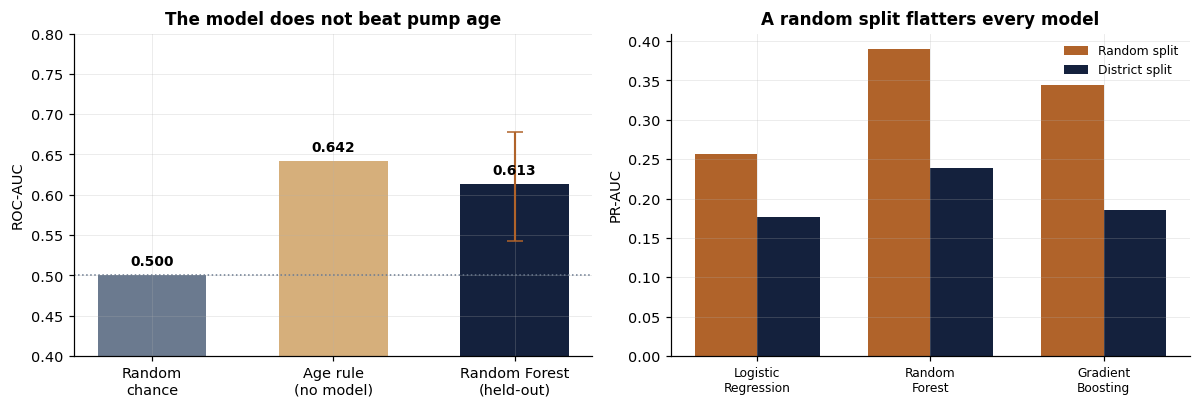

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

# Held-out comparison against the benchmarks that matter.
names = ["Random\nchance", "Age rule\n(no model)", f"{best_name}\n(held-out)"]
vals = [0.5, roc_auc_score(yte, rule_te), roc_auc_score(yte, p_te)]
cols = [SLATE, GOLD, NAVY]
bars = axes[0].bar(names, vals, color=cols, width=0.6)
axes[0].errorbar(2, vals[2], yerr=[[vals[2]-auc_lo], [auc_hi-vals[2]]],
                 fmt="none", ecolor=RUST, capsize=5, lw=1.4)
axes[0].axhline(0.5, color=SLATE, ls=":", lw=1)
axes[0].set_ylim(0.4, 0.8); axes[0].set_ylabel("ROC-AUC")
axes[0].set_title("The model does not beat pump age")
for b, v in zip(bars, vals):
    axes[0].text(b.get_x() + b.get_width()/2, v + 0.012, f"{v:.3f}",
                 ha="center", fontsize=9, weight="600")

# Optimism from a careless split.
sc = split_comparison.set_index("Model")
xp = np.arange(len(sc)); w = 0.36
axes[1].bar(xp - w/2, sc["Random split PR-AUC"], w, label="Random split", color=RUST)
axes[1].bar(xp + w/2, sc["District split PR-AUC"], w, label="District split", color=NAVY)
axes[1].set_xticks(xp)
axes[1].set_xticklabels([m.replace(" ", "\n") for m in sc.index], fontsize=8)
axes[1].set_ylabel("PR-AUC"); axes[1].legend(frameon=False, fontsize=8)
axes[1].set_title("A random split flatters every model")

plt.tight_layout(); plt.show()

## 13. The question a water officer actually asks

PR-AUC is not a thing anyone can act on. The real question is operational:

> *A crew can reach the top 20% of the water points in a district this month.
> How many of the broken ones will they find?*

That is a ranking question, and a model can be useful for ranking even when its
headline score is unimpressive.

In [20]:
curve = inspection_curve(yte, p_te)
print("If a repair crew can only reach part of the district:\n")
print(curve.to_string(index=False))

r20 = curve[curve.visit_top_pct == 20].iloc[0]
print(f"\nVisiting the top 20% by model rank finds {r20.broken_found} of "
      f"{r20.of_total_broken} broken points ({r20.recall_at_k*100:.0f}%),")
print(f"which is {r20.lift_vs_random}x better than arbitrary order.")
print("Real, but modest. And the age rule would deliver much of it for free.")

If a repair crew can only reach part of the district:

 visit_top_pct  points_visited  broken_found  of_total_broken  precision_at_k  recall_at_k  lift_vs_random
             5              33            10               83           0.303        0.120            2.44
            10              67            16               83           0.239        0.193            1.92
            20             134            31               83           0.231        0.373            1.86
            30             201            38               83           0.189        0.458            1.52
            50             334            51               83           0.153        0.614            1.23

Visiting the top 20% by model rank finds 31.0 of 83.0 broken points (37%),
which is 1.86x better than arbitrary order.
Real, but modest. And the age rule would deliver much of it for free.


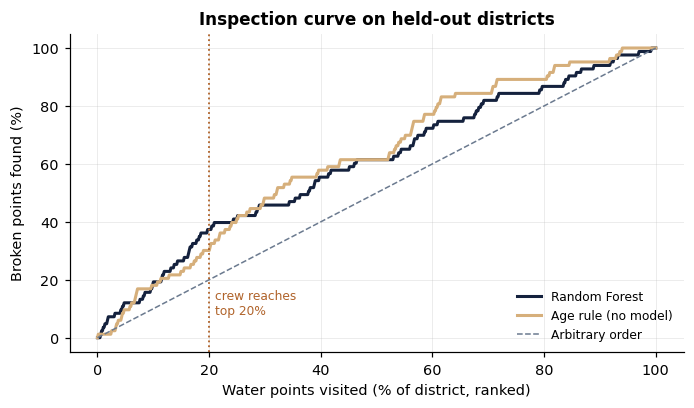

In [21]:
fig, ax = plt.subplots(figsize=(6.4, 3.8))
frac = np.linspace(0, 1, len(yte) + 1)
order = np.argsort(-p_te)
gains = np.concatenate([[0], np.cumsum(yte[order]) / yte.sum()])
rorder = np.argsort(-rule_te)
rgains = np.concatenate([[0], np.cumsum(yte[rorder]) / yte.sum()])

ax.plot(frac * 100, gains * 100, color=NAVY, lw=2, label=best_name)
ax.plot(frac * 100, rgains * 100, color=GOLD, lw=2, label="Age rule (no model)")
ax.plot([0, 100], [0, 100], color=SLATE, ls="--", lw=1, label="Arbitrary order")
ax.axvline(20, color=RUST, ls=":", lw=1.2)
ax.text(21, 8, "crew reaches\ntop 20%", fontsize=8, color=RUST)
ax.set_xlabel("Water points visited (% of district, ranked)")
ax.set_ylabel("Broken points found (%)")
ax.set_title("Inspection curve on held-out districts")
ax.legend(frameon=False, fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

## 14. What the model actually leaned on

Tree impurity importances are biased towards high-cardinality features, so this
uses **permutation importance**, measured on the held-out districts: shuffle one
column, see how much PR-AUC falls.

In [22]:
perm = permutation_importance(best, X_te, y_te, n_repeats=30,
                              random_state=RANDOM_STATE,
                              scoring="average_precision", n_jobs=-1)
imp = (pd.DataFrame({"feature": MODEL_FEATURES,
                     "importance": perm.importances_mean,
                     "std": perm.importances_std})
       .sort_values("importance", ascending=False))
print("Drop in PR-AUC when the column is shuffled:\n")
print(imp.to_string(index=False))

Drop in PR-AUC when the column is shuffled:

              feature  importance      std
            age_years    0.043107 0.021029
  distance_to_primary    0.024044 0.006547
     distance_to_town    0.022414 0.010921
  water_tech_category    0.008900 0.011276
   water_source_clean    0.004912 0.002790
     water_tech_clean    0.003492 0.008791
     distance_to_city    0.002796 0.016680
     local_population    0.001199 0.007739
water_source_category   -0.000007 0.001094
             is_urban   -0.000844 0.008796
 distance_to_tertiary   -0.015274 0.009194
distance_to_secondary   -0.018302 0.009476
           clean_adm1   -0.026622 0.018159


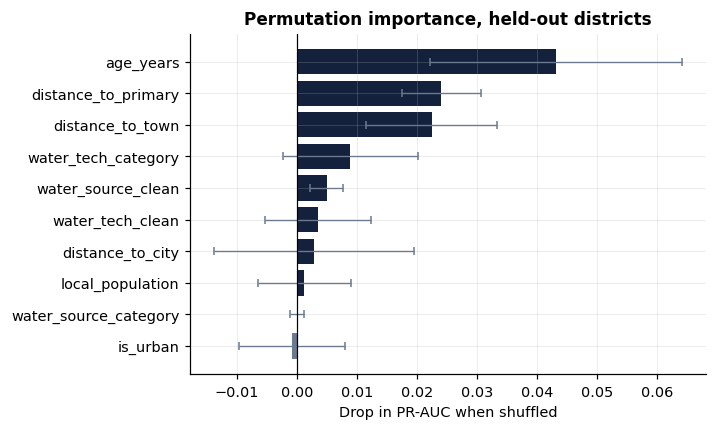

In [23]:
fig, ax = plt.subplots(figsize=(6.6, 4))
top = imp.head(10).iloc[::-1]
ax.barh(top["feature"], top["importance"], xerr=top["std"],
        color=[NAVY if v > 0 else SLATE for v in top["importance"]],
        error_kw=dict(ecolor=SLATE, lw=0.9, capsize=2.5))
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Drop in PR-AUC when shuffled")
ax.set_title("Permutation importance, held-out districts")
plt.tight_layout(); plt.show()

## 15. Ablation: do coordinates help, or do they help it memorise?

Latitude and longitude are excluded from the model. That decision was made in
`src/ablation.py`, **on the training districts only**, so it could never be
tuned against the test set.

The suspicion: exact coordinates let a model memorise neighbourhoods, which is
worth nothing in a district it has never visited.

In [24]:
ab_path = ROOT / "reports" / "ablation.csv"
if ab_path.exists():
    ab = pd.read_csv(ab_path)
    print(ab.to_string(index=False))
    print("\nRemoving coordinates did not hurt performance in an unseen district,")
    print("which is exactly what you expect if they were being used to memorise")
    print("rather than to learn something that travels. So they are dropped.")
else:
    print("Run: python src/ablation.py")

                         features  model   pr_auc  pr_auc_std  roc_auc  n_features
                B. No coordinates     RF 0.238756    0.147136 0.613530          13
                    A. Everything     RF 0.227209    0.114558 0.610929          15
                     E. Age alone GBoost 0.219628    0.158359 0.649908           1
                     E. Age alone     RF 0.219305    0.156498 0.651121           1
   C. No coordinates, no province     RF 0.213554    0.122869 0.572122          12
                    A. Everything LogReg 0.206918    0.151385 0.581105          15
                    A. Everything GBoost 0.194366    0.094662 0.550887          15
                     E. Age alone LogReg 0.187465    0.100846 0.614366           1
                B. No coordinates GBoost 0.185112    0.093234 0.564915          13
D. Asset only (age, tech, source)     RF 0.181510    0.067263 0.620782           5
                B. No coordinates LogReg 0.177475    0.106453 0.541168          13
D. A

## 16. What I would defend, and what I would not

### The findings, in order of importance

1. **`status_clean` is unusable.** Fourteen of the fifteen contributing
   programmes never record a functional water point. It encodes who uploaded
   the record, not whether the water flows. Anyone using this dataset should
   check this before doing anything else.
2. **Two columns leak the answer.** `rehab_priority` and `would_gain_access` are
   populated for ~97% of failures and 0.0% of working points. Left in, ROC-AUC
   reaches 0.998 and means nothing.
3. **Seven programmes report a 0% failure rate**, covering 2,171 points,
   because they upload at handover and never return.
4. **A random split overstates PR-AUC by 63%** compared with holding out whole
   districts.
5. **The model does not beat pump age.** 0.613 against 0.642 on unseen
   districts.

### Method choices I would defend in an interview

- `StratifiedGroupKFold` grouped on district, not a random split
- Every transform inside a `Pipeline`, so imputation is fitted per fold
- Permutation importance rather than tree impurity
- Bootstrap confidence intervals, because 83 failures is not many
- The age rule scored on identical folds as the benchmark that matters
- Coordinates dropped on ablation evidence gathered before the test set was touched

### Limitations I will not talk around

- **669 test points and 83 failures.** The confidence intervals are wide and I
  am not going to pretend otherwise.
- **The label is "was water available on the day of the visit"**, which is not
  the same as "the pump is broken". A dry season visit and a mechanical failure
  look identical in this data.
- **Survivorship.** Points that were abandoned entirely may never have been
  surveyed at all.
- **Excluding the zero-failure programmes removed a third of the labelled
  data.** That is a defensible call, not a free one.

### The conclusion that actually mattered

The reason this model cannot predict much is not that it needs more trees or
better tuning. It is that **the underlying measurement does not exist**. Nobody
goes back to a water point after handover to record whether it still works, so
there is no signal to learn from. No amount of modelling creates a fact that was
never written down.

That realisation is what the follow-on project is built on: an SMS reporting
and verification loop that generates the dated functionality records this
dataset has never had.

**<https://github.com/buseko-Actuary/pump-watch>**

Finding out that a model does not work, and being able to prove why, is a
result. Publishing a number you cannot defend is not.

---

*Data: Water Point Data Exchange via UN OCHA HDX, CC BY-SA. Every figure in
this notebook was produced by the cells above.*